# A Trilha Acadêmica

**Autor:** Matheus Nascimento Cunha

## O Olho Biônico das CNN

As CNN - _Convolutional Neural Networks_ - são um tipo de redes neurais artificiais utilizadas para processar dados estruturados em grade, sendo o processamento e o reconhecimento de imagens o principal exemplo do seu uso. Elas tem como inspiração pesquisas realizadas nas décadas de 50 e 60 de neurociência visual, e representam um modelo simplificado da forma como o cérebro enxerga imagens [1]. Isso permite esse tipo de _Deep learning_ ser usado desde classificação e segmentação de imagem (como em diagnósticos médicos por imagens) até sistemas de segurança (como reconhecimento facial). 

Diferentemente das redes neurais tradicionais, que empregam as matrizes de multiplicação entre as camadas, as CNN empregam operações de **convolução**. Com isso, capturam automaticamente padrões espaciais e hierárquicos nas imagens, reduzindo a necessidade de engenharia manual na etapa de pré-processamento de características.

## Convolução em 2D

Nos estudos que serviram como base para as CNN, os pesquisadores identificaram uma comunicação entre neurônios que reconhecem padrões mais simples, como bordas e orientação espacial, com neurônios que reconhecem padrões mais complexos, como textura. Nessas redes neurais, quem faz o papel de reconhecimento de padrões locais são os **operadores de convolução**, que realizam a atividade central de uma CNN. Um operador de convolução combina duas funções matemáticas para produzir uma terceira. Nesse caso, por se tratar de imagens (matrizes de _pixels_), a definição formal desse operador se dá pela forma discreta:
$$
(f * g)(x,y) = \sum_{i}\sum_{j}f(i,j)g(x-i,y-j)
$$

Vamos tratar de uma convolução bidimensional. Esse tipo de convolução consiste em "deslizar" um pequeno filtro sobre uma imagem, em que o valor da convolução mede o quanto o padrão do filtro está presente na vizinhança daquela imagem. Em uma imagem 2D, pode-se tratar de duas funções:
- Uma função $f(x,y)$: a própria imagem;
- Uma função $g(x,y)$: o filtro

Com isso, pode-se notar uma outra característica das CNN, que é a esparsidade. Diferentemente das matrizes de multiplicação nas redes neurais tradicionais, em que todo _output_ interage com todo _input_, as CNN possuem interações esparsas (o que, na prática, quer dizer que o nosso filtro (ou _kernel_, será menor que a imagem)[5]. Para exemplificar e ilustrar o que está sendo dito, vamos tratar de imagens reais.

## Exemplo didático

Agora, vamos analisar uma imagem real, `"tiles.png"`, que propositalmente possui muitas bordas e formas geométricas, para testar a capacidade de "visualização" das CNN. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np

img = plt.imread("tiles.png")
print(img.shape)

(320, 320, 3)


Note que a imagem acima trata de 3 dimensões (H, W, C) respectivas de altura (Height), largura (Width) e canais de cores (Channels). Para os nossos fins, vamos desconsiderar os canais de cores, de modo a tentar enxergar a imagem em preto e branco, com apenas duas dimensões. 

**Obs:** Apesar de estarmos removendo os canais para realizar uma convolução 2D, a adição de cores em uma imagem não atribui à convolução a qualidade de ser tridimensional. Quando há o tratamento de uma imagem colorida, trata-se de uma convolução 2D com profundidade (que seriam justamente os canais de cor).

In [2]:
img_gray = np.mean(img, axis=2)
print(img_gray.shape)

(320, 320)


Agora, delimitaremos o nosso _kernel_, ou filtro. O _kernel_ mais simples que se pode ter é o Laplaciano [3], em que a função da imagem, de duas variáveis, pode ser definida por:
$$
\nabla ^2=\frac{\partial ^2 f}{\partial x^2} + \frac{\partial ^2f}{\partial y^2}
$$

A partir desse Laplaciano, algumas relações podem ser estabelecidas, como, por exemplo, o Laplaciano discreto de duas variáveis, que é justamente a representação discreta do operador de convolução em um ponto. Reescrevendo esses termos em forma matricial, chegaremos em:

In [3]:
kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

Agora, para realizar a convolução, pode-se utilizar o módulo `scipy.signal`. Esse módulo da biblioteca `scipy`, dentre outras funções, realiza convoluções em matrizes numpy.

In [4]:
from scipy.signal import convolve2d

resultado = convolve2d(img_gray, kernel, mode='same')

Agora, resta plotar a imagem. Por fins didáticos, plotarei a imagem original (mas em preto e branco) ao lado.

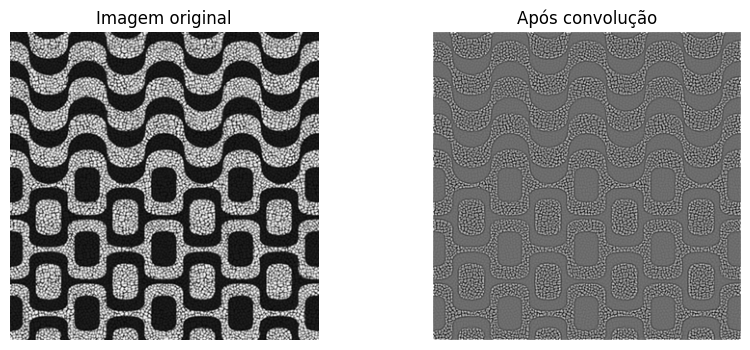

In [5]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Imagem original")
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Após convolução")
plt.imshow(resultado, cmap='gray')
plt.axis('off')

plt.show()

Com essa demonstração, é possível notar que as CNN necessitam de menos parâmetros quando comparada às redes neurais clássicas. A esparsidade que esse tipo de processamento de dados possui permite que, mesmo que a imagem de _input_ tenha centenas de milhões de _pixels_, é possível detectar detalhes pequenos e relevantes (como bordas) utilizando um filtro que ocupa dezenas ou centenas de _pixels_. Isso reduz o impacto computacional (além do fato de reduzir consideravelmente o número de operações necessárias) do modelo e aumenta a eficiência estatística do processo.

Além disso, como o mesmo _kernel_ é utilizado em toda a imagem, essa análise gera uma **equivariância de translação**. Em um contexto matemático, a equivariância refere-se a uma condição na qual uma função fornece a mesma saída, embora com uma ordem diferente, quando a ordem da entrada sobre a qual ela atua muda. Nesse caso, quer dizer que se um padrão aparece na imagem (como uma borda), o filtro responderá do mesmo jeito por toda a imagem. Assim, se a imagem deslocar, a resposta também deslocaria, gerando uma precisão a nível de pixels. 

## To pooling or not to pooling

Em redes neurais, _pooling_ é uma etapa que reduz e agrega informação que está dispersa em vários vetores em uma menor quantidade deles.  Uma função _pooling_ substitui o _output_ de uma rede em um certo ponto por um dado de estatística descritiva dos _outputs_ ao redor. Isso ajuda a tornar a representação aproximadamente invariante a pequenas translações do _input_, ou seja, se a imagem deslocar nesse caso, a resposta dos _pooled outputs_ não responderia. 

Isso é extremamente relevante dependendo do objetivo do tratamento daqueles dados, principalmente quando se importa mais sobre a presença ou não de certo objeto do que exatamente onde ele está. Por exemplo, se o objetivo for determinar a quantidade de núcleos de células animais em uma imagem de microscopia, não importa se o objeto `nucleo_A` está a 20 ou a 22 _pixels_ de distância do objeto `nucleo_B`. No entanto, se estamos trabalhando com imagens de interações proteicas, em que é mais relevante reconhecer **precisamente** o local onde a proteína se conecta a um receptor de membrana, a função _pooling_ geraria erros de interpretação. 

Uma função exemplo de _pooling_ é a função Max Pooling. Assim como mencionado, essa operação divide a entrada em pequenas regiões e, em cada uma delas vai selecionar o maior valor. Ao invés de preservar todos os detalhes, essa técnica descarta os valores menores e mantém os sinais mais fortes, o que torna o modelo mais eficiente computacionalmente e mais robusto a pequenas variações na posição das características. Embora isso implique perda de informação espacial (que leva a uma simplificação das estruturas das imagens, sem muitos detalhes), o objetivo dessa estratégia não é reconstruir a imagem original, mas destacar padrões importantes em diferentes regiões.



![Img](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*px_9GmRXLOAmscAN54d3xw.jpeg)

`Imagem representativa do max pooling. Disponível em [6]`

Abaixo, definiremos essa função em python puro. Para que fique mais didático, colocarei a linha de raciocínio que se deve tomar para tal:
1. Deve-se dividir a imagem em uma grade que contém algura (h) e largura (w);
2. Escolher o tamanho do _pool_. No exemplo abaixo foi 2x2, então ele analisa 4 _pixels_ por vez;
3. Dividir a imagem pelo tamanho do _pool_;
4. Pegar o primeiro bloco 2x2
5. Pegar o primeiro pixel desse bloco e armazenar. Se o segundo bloco for maior que esse, armazenar esse. Caso contrário, segue o maior número;
6. Quando passar pelos 4 _pixels_ desse bloco, seguir para o próximo bloco;
7. Assim que se acabar a primeira linha, seguir para a próxima linha, até o fim da imagem. 

In [6]:
def max_pooling_puro(img, pool_size):
    h = len(img)
    w = len(img[0])
    
    # tamanho da saída
    h_new = h // pool_size
    w_new = w // pool_size
    
    pooled = []
    
    for i in range(h_new):
        linha = []
        for j in range(w_new):
            
            max_val = float('-inf')
            
            for di in range(pool_size):
                for dj in range(pool_size):
                    
                    val = img[i*pool_size + di][j*pool_size + dj]
                    
                    if val > max_val:
                        max_val = val
            
            linha.append(max_val)
        
        pooled.append(linha)
    
    return pooled

Agora, vamos comparar a imagem de convolução com a imagem de _pooling_.

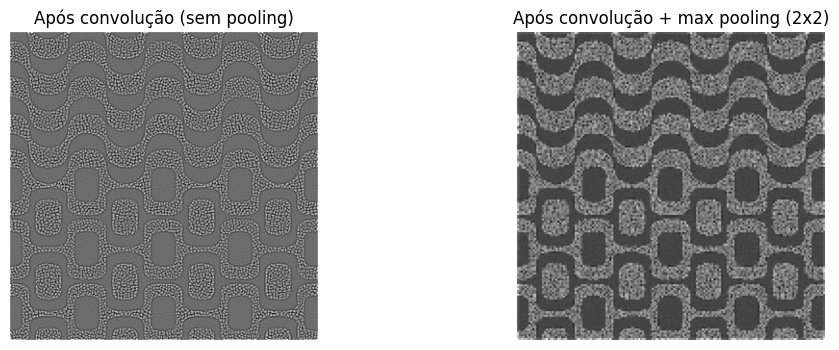

In [7]:
pooled = max_pooling_puro(resultado, pool_size=2)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title("Após convolução (sem pooling)")
plt.imshow(resultado, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Após convolução + max pooling (2x2)")
plt.imshow(pooled, cmap='gray')
plt.axis('off')

plt.show()

Note que o _Max pooling_ reduz a resolução espacial ao selecionar os maiores valores em regiões locais. Isso tende a preservar ativações fortes e descartar valores menores, o que pode dar a impressão de maior contraste, embora não seja uma operação de aumento de contraste no sentido clássico, como em edição de fotos.

Até o momento, utilizamos o `scipy.signal` para implementar a convolução e definimos a função `max_pooling_puro` para fazermos a estratégia de _pooling_. Ambas essas etapas podem ser realizadas diretamente no `pytorch`, com alguns cuidados a mais.

## Realizando convolução no `PyTorch`

O `PyTorch` é uma biblioteca de código aberto amplamente utilizada para aprendizado de máquina e, em especial, para o desenvolvimento de redes neurais. Ele se destaca por sua interface intuitiva e por utilizar tensores (estruturas semelhantes a `arrays`) com suporte a aceleração por GPU, permitindo a construção e o treinamento eficiente de modelos complexos. Além disso, seu sistema de autograd realiza automaticamente o cálculo de derivadas, o que facilita a implementação de algoritmos de otimização. 

Agora, implementaremos uma CNN na mesma imagem para compararmos o uso do `Pytorch` com o que foi feito até o momento. 

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from PIL import Image

imagem = Image.open("tiles.png").convert("L")

transform = transforms.ToTensor()
img_tensor = transform(imagem).unsqueeze(0)

No código acima, abrimos a imagem e a convertemos para `"L"`, diferentemente do que realizamos com `numpy`, para gerarmos uma escala em cinza por _pixels_. Essa diferença se dá porque, diferentemente do que foi feito anteriormente, não é uma média aritmética entre as cores RGB. Essa conversão coloca pesos estabelecidos para traduzir essa informação apenas como um valor de intensidade. 

Em seguida, a imagem é convertida para um tensor do `PyTorch`, que é o formato necessário para operações em redes neurais. Essa transformação também normaliza os valores dos _pixels_ (entre 0 e 1) e reorganiza os dados para o formato (H, W, C). Depois, adiciona-se uma dimensão extra para representar o "batch", resultando em (H, W, 1, 1).

In [9]:
conv = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    padding=1,
    bias=False
)


Aqui é criada uma camada de convolução 2D. Ela está configurada para receber uma imagem com um canal (grayscale) e produzir uma saída também com um canal. O kernel tem tamanho 3×3, e o padding garante que a saída tenha o mesmo tamanho da entrada.

In [10]:
with torch.no_grad():
    conv.weight[:] = torch.tensor([[[[-1., -1., -1.],
                                     [-1.,  8., -1.],
                                     [-1., -1., -1.]]]])

Neste passo, o código substitui os valores aleatórios do kernel por um filtro específico (o Laplaciano), utilizado anteriormente. No `PyTorch`, podemos treinar um modelo para encontrar um kernel melhor, como será demonstrado mais adiante. Como estamos comparando os métodos, utilizaremos o mesmo kernel. Então, pode-se aplicar a convolução e a estratégia de _max pooling_.

In [11]:
saida_conv = conv(img_tensor)
pool = nn.MaxPool2d(kernel_size=2, stride=2)
saida_pool = pool(saida_conv)

Para exibirmos a imagem em `matplotlib`, os tensores precisam ser convertidos em `arrays` novamente. Após isso, é possível gerar as imagens.

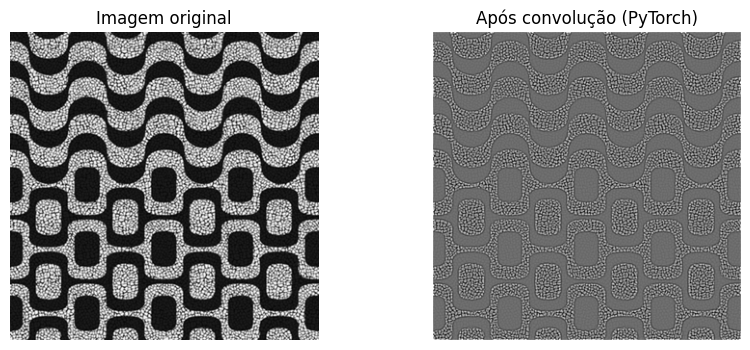

In [12]:
img_original = img_tensor.squeeze().numpy()
img_conv = saida_conv.detach().squeeze().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Imagem original")
plt.imshow(img_original, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Após convolução (PyTorch)")
plt.imshow(img_conv, cmap='gray')
plt.axis('off')

plt.show()

Agora que geramos essa imagem, vamos ver como podemos treinar um modelo que gera um _kernel_. Para isso, teremos que criar um alvo capaz de identificar bordas (usaremos a mesma ideia, com um _kernel_ do Laplaciano). Após isso, criaremos um modelo que imitará esse modelo que sabe encontrar bordas. Assim, conseguimos obter um _kernel_ novo e otimizado.

In [13]:
img_np = img_tensor.squeeze().numpy()

kernel_ref = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

target_np = convolve2d(img_np, kernel_ref, mode='same')
target_tensor = torch.tensor(target_np).unsqueeze(0).unsqueeze(0).float()

Agora, uma nova camada de convolução é criada, mas desta vez sem definir o _kernel_ manualmente. Isso significa que os pesos começam com valores aleatórios. Então diferentemente da célula anterior, o modelo não sabe qual filtro usar, obrigando-o a aprender.

Em seguida, o código define **como** o modelo vai aprender. O otimizador `optim.Adam` será responsável por ajustar os valores do _kernel_, enquanto a função de perda (erro quadrático médio) mede o quão diferente está a saída do modelo em relação ao alvo. O otimizador escolhido possui o diferencial de se adaptar ao aprendizado à medida que avança nos dados.

Em vez de atualizar todos os parâmetros do modelo da mesma forma, ele observa o histórico recente dos gradientes: se um parâmetro está oscilando muito, o `Adam` reduz o tamanho do passo; se está evoluindo de forma consistente, ele permite avanços maiores. Ao mesmo tempo, ele mantém uma espécie de "inércia", que ajuda a seguir direções promissoras sem ficar preso em pequenas variações locais. Com isso, o treinamento tende a ser mais estável, eficiente e menos sensível à escolha inicial da taxa de aprendizado.

In [14]:
conv = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)

optimizer = optim.Adam(conv.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

Agora, o modelo entrará em ciclos (épocas). Em cada iteração, ele aplicará a convolução na imagem, comparará com a imagem guia, calculará o erro e ajusta o _kernel_ com base nesse erro. No nosso caso, utilizaremos 200 épocas. Após isso, podemos plotar nossas imagens.

Epoch 0, Loss: 1.0669
Epoch 50, Loss: 0.7995
Epoch 100, Loss: 0.6473
Epoch 150, Loss: 0.5132
Kernel aprendido:
 [[-0.76089203  0.41413945 -0.7650084 ]
 [ 0.26091242  1.710352    0.50614685]
 [-0.79331654  0.54896677 -1.036227  ]]


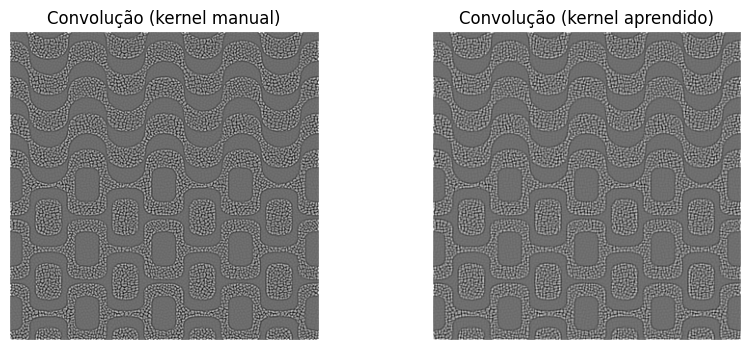

In [15]:
for epoch in range(200):
    optimizer.zero_grad()
    
    output = conv(img_tensor)
    loss = loss_fn(output, target_tensor)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

saida_conv = conv(img_tensor)

kernel_aprendido = conv.weight.detach().squeeze().numpy()
print("Kernel aprendido:\n", kernel_aprendido)

img_conv_learned = saida_conv.detach().squeeze().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Convolução (kernel manual)")
plt.imshow(img_conv, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Convolução (kernel aprendido)")
plt.imshow(img_conv_learned, cmap='gray')
plt.axis('off')

plt.show()

Note que, em essência, o _kernel_ aprendido não é imposto, mas emerge como solução para o problema dado, que era reproduzir uma imagem com um _kernel_ escolhido anteriormente. O aprendizado do _kernel_ ocorre como um problema de otimização: a rede começa com valores aleatórios e ajusta esses valores iterativamente para minimizar a diferença entre sua saída e o resultado desejado. A cada passo do treinamento, o erro é calculado (no nosso caso, via `MSE`), e o algoritmo de _backpropagation_ determina como cada peso do _kernel_ deve ser modificado para reduzir esse erro. Isso é fundamental para problemas científicos reais, cujos padrões mais relevantes não são de conhecimento prévio. Com essa estratégia, as CNNs resolvem isso aprendendo automaticamente os filtros mais úteis diretamente dos dados. Este exemplo não treina uma CNN completa, mas ilustra como _kernels_ podem ser aprendidos automaticamente.

## Aplicação das CNNs num contexto científico.

No último exemplo dado, foi demonstrado como, a partir de um objetivo claro, a CNN aprendeu a identificar uma imagem. Em uma situação real de pesquisa, o objetivo se torna mais implícito (como detectar objetos, padrões etc). Em pesquisas de imagens biológicas, por exemplo, muito comuns nos laboratórios nacionais do CNPEM, como o LNBio, há uma etapa no tratamento das imagens chamada de **segmentação celular**, que consiste no uso de ferramentas computacionais para identificar e delimitar automaticamente cada célula (ou suas partes, como núcleo e citoplasma) em uma imagem. Isso significa atribuir a cada _pixel_ da imagem um rótulo, por exemplo: `pixel (1,1)`: pertence a uma célula; ou `pixel (x,y)`: fundo, ou até mesmo uma contagem de células ao longo da imagem.

Nesse contexto, alguns modelos inspirados em redes neurais de convolução foram desenvolvidos. É o caso do `cellpose`, que é um modelo de segmentação celular baseado em CNNs, projetado para segmentar células em imagens microscópicas de forma generalista, ou seja, sem precisar treinar um modelo específico para cada tipo de célula ou experimento. Esse modelo usa uma arquitetura do tipo `U-net`, que é uma CNN caracterizada por um processo de codificação e decodificação: inicialmente, aplica operações como convolução e _pooling_ para extrair características e reduzir a dimensionalidade da imagem, e posteriormente realiza _upsampling_ para recuperar a resolução espacial, permitindo segmentações mais precisas.

Diferentemente de uma CNN clássica, o `Cellpose` prevê campos de fluxo que guiam a reconstrução das células, em vez de apenas classificar pixels diretamente. Isso significa que o modelo atribui uma direção com sentido para o centro da célula a qual cada _pixel_ pertence, criando um campo vetorial em que todos os pontos dentro de uma célula apontam para o centro dela. Durante essa inferência, os _pixels_ seguem esse campo até convergirem em centros comuns, o que permite que agrupem regiões que pertencem à mesma célula. Essa metodologia contrasta com as CNNs clássicas de segmentação celular, que normalmente atribuem rótulos diretamente para cada _pixel_ de forma independente.

Agora, vamos ver e compreender como o `Cellpose` funciona em um contexto de dados reais. Esse modelo, dado ao seu nível de complexidade e esforço computacional, deve ser rodado em GPU. As nuances do código não serão apresentadas nesse notebook, dado que não está dentro do propósito dele. O exemplo abaixo é apenas uma estratégia didática de demonstrar o uso das CNN em uma rotina real de laboratório. Para compreender as nuances do código e a teoria por trás do `Cellpose`, olhe as referências [8,9].

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


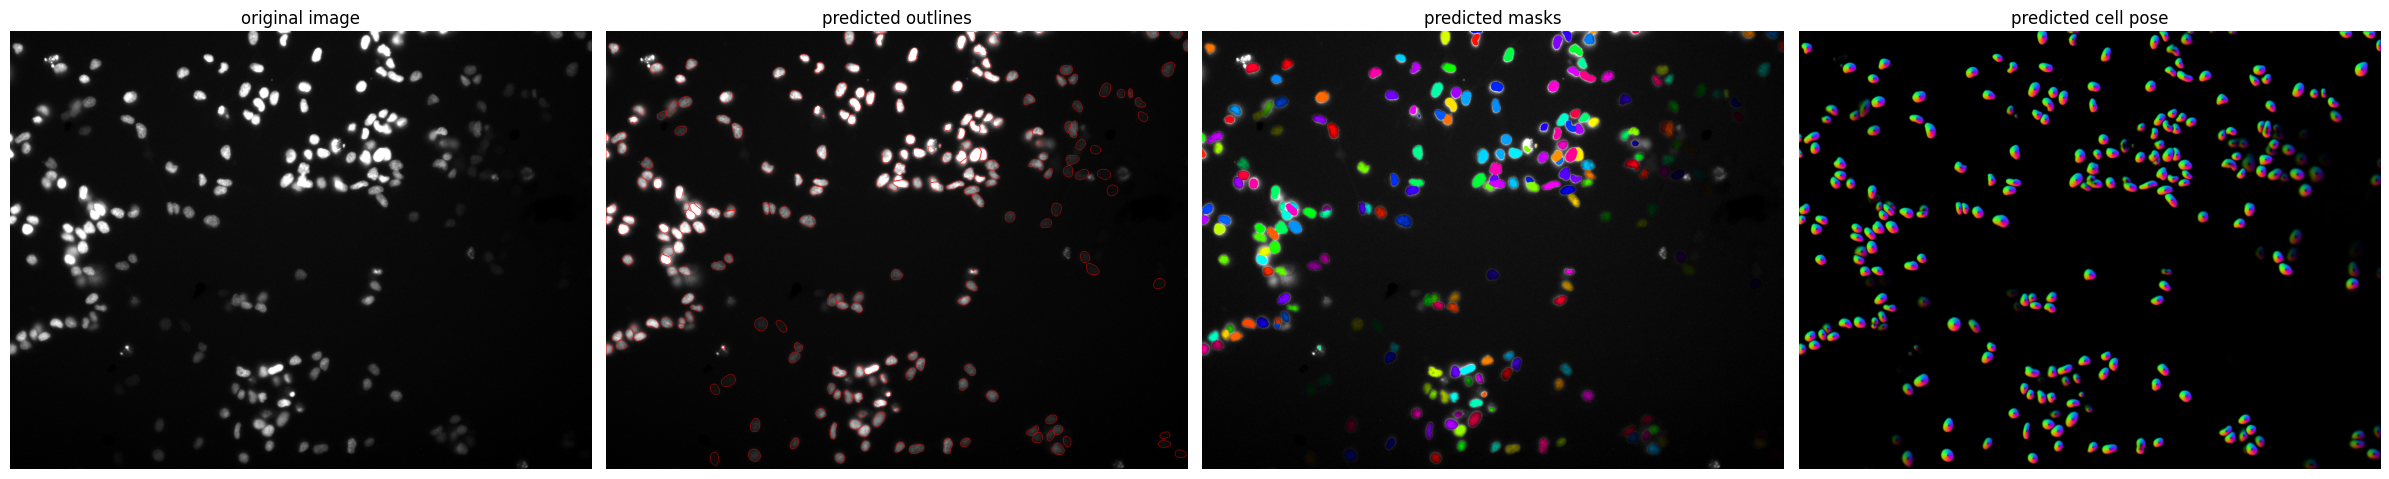

In [16]:
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
from natsort import natsorted
import tifffile as tiff

dir = "003012-1-001001002.tif"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

image_ext = ".tif"



model = models.CellposeModel(gpu=True)

files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

img = io.imread(dir)

first_channel = '0'
second_channel = '1'
third_channel = '2' 

masks, flows, styles = model.eval(img)

masks, flows, styles = model.eval(img, channels=[0,0])

fig = plt.figure(figsize=(24,10))
plot.show_segmentation(fig, img, masks, flows[0])
plt.tight_layout()
plt.show()

A série de imagens plotadas foi disposta de modo a compreender, ainda que de forma introdutória, o que as CNNs podem fazer. Inicialmente, na imagem `predicted outlines`, o `Cellpose` identifica as bordas dos objetos presentes na imagem. Em seguida, em `predicted masks`, cada objeto ou célula da imagem de microscopia é segmentado e rotulado individualmente. Por fim, o algoritmo consegue delimitar cada célula de forma precisa, utilizando seu método próprio de segmentação.

## Referências

1. Wikipédia - Convolutional Neural Networks (https://en.wikipedia.org/wiki/Convolutional_neural_network);
2. Wikipédia - Convolution (https://en.wikipedia.org/wiki/Convolution);
3. Gonzalez e Woods - Digital Image Processing 4a edição (https://www.cl72.org/090imagePLib/books/Gonzales,Woods-Digital.Image.Processing.4th.Edition.pdf);
4. Documentação do `scipy.signal`: https://docs.scipy.org/doc/scipy/reference/signal.html;
5. Ian Goodfellow - DEEP LEARNING: (Disponível na biblioteca da Ilum);
6. Medium - Max Pooling: (https://medium.com/@ilyurek/what-is-max-pooling-and-why-do-we-need-max-pooling-57247a3fbca9);
7. Documentação do `torch.nn`: https://docs.pytorch.org/docs/stable/nn.html
8. Artigo do funcionamento do `Cellpose`: https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1;
9. Github do `Cellpose`: https://github.com/MouseLand/cellpose/blob/main/README.md 